In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("C:/data_science/Projects/Customer_Churn_Analysis/data/raw/telco_customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:

df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df.duplicated().sum()

0

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# Data Cleaning 

In [12]:
df.columns=df.columns.str.strip()

In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.rename(columns={"customerID":"customer_id","SeniorCitizen":"senior_citizen","MultipleLines":"multiple_lines",
                  "InternetService":"internet_service","OnlineSecurity":"online_security","OnlineBackup":"online_backup",
                  "DeviceProtection":"device_protection","TechSupport":"tech_support","StreamingTv":"streaming_tv",
                  "StreamingMovies":"streaming_movies","PaperlessBilling":"paperless_billing",
                "PaymentMethod":"payment_method","MonthlyCharges":"monthly_charges","TotalCharges":"total_charges"},inplace=True)

In [15]:
df.columns=df.columns.str.lower()

In [16]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phoneservice,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streamingtv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.tail()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phoneservice,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streamingtv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [18]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streamingtv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phoneservice       7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streamingtv        7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [20]:
# since total charges is object showing but actully it is numeric so convert them 
df["total_charges"]=pd.to_numeric(df["total_charges"],errors='coerce')

In [21]:
# Dropping Duplicates
df.duplicated().sum()

0

In [22]:
# since there is no duplicates if duplicates are present then 
# df=df.drop_duplicates()

In [23]:
# Check missing values
df.isnull().sum()


customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phoneservice          0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streamingtv           0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [24]:
df["total_charges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: total_charges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


<Axes: >

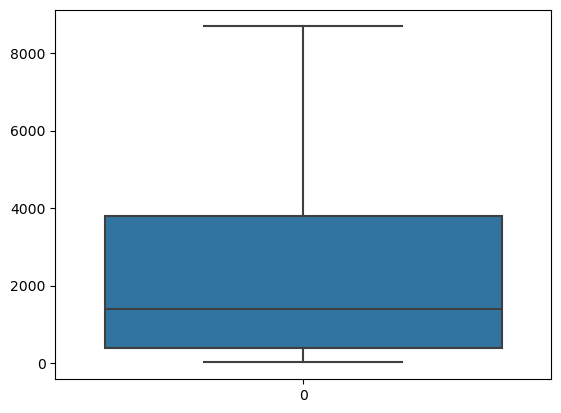

In [25]:
# Checking outliers in total_charges
sns.boxplot(df["total_charges"])


In [26]:
# no outliers on total_charges so filling with mean
df["total_charges"]=df["total_charges"].fillna(df["total_charges"].mean())

In [27]:
df["total_charges"].isnull().sum()

0

In [28]:
# Handling Outliers
# Handling outliers of (Numerical Columns: tenure,monthlycharges,totalcharges
for col in ["tenure","monthly_charges","total_charges"]:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower= q1-1.5 * IQR
    upper=q3+1.5 * IQR
    outliers= df[(df[col]<lower) | (df[col]>upper)]
    print(f"{col} outliers count:", outliers.shape[0])
    
    # cap outliers
    
    df[col]=np.where(df[col]<lower,lower,df[col])
    df[col]=np.where(df[col]>upper,upper,df[col])
    
    print (df.describe())

tenure outliers count: 0
       senior_citizen       tenure  monthly_charges  total_charges
count     7043.000000  7043.000000      7043.000000    7043.000000
mean         0.162147    32.371149        64.761692    2283.300441
std          0.368612    24.559481        30.090047    2265.000258
min          0.000000     0.000000        18.250000      18.800000
25%          0.000000     9.000000        35.500000     402.225000
50%          0.000000    29.000000        70.350000    1400.550000
75%          0.000000    55.000000        89.850000    3786.600000
max          1.000000    72.000000       118.750000    8684.800000
monthly_charges outliers count: 0
       senior_citizen       tenure  monthly_charges  total_charges
count     7043.000000  7043.000000      7043.000000    7043.000000
mean         0.162147    32.371149        64.761692    2283.300441
std          0.368612    24.559481        30.090047    2265.000258
min          0.000000     0.000000        18.250000      18.800000
25%

In [29]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phoneservice,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streamingtv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


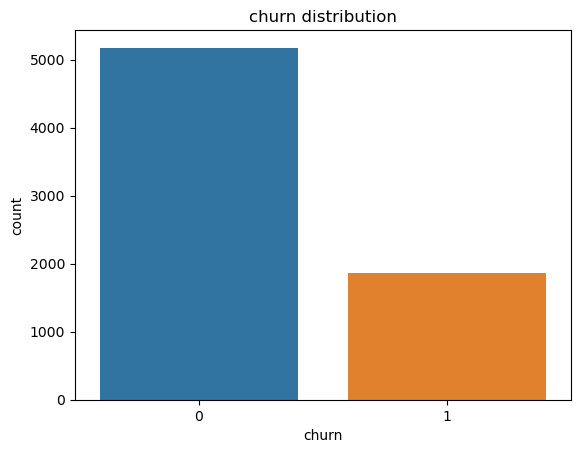

churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [30]:
# Churn Distribution 

import seaborn as sns 
import matplotlib.pyplot as plt 

df["churn"]=df["churn"].map({"Yes":1,"No":0})

# plot
sns.countplot(x="churn",data=df)
plt.title("churn distribution")
plt.show()

# Percentage
print(df["churn"].value_counts(normalize=True)*100)

In [31]:
# Numerical features vs churn 

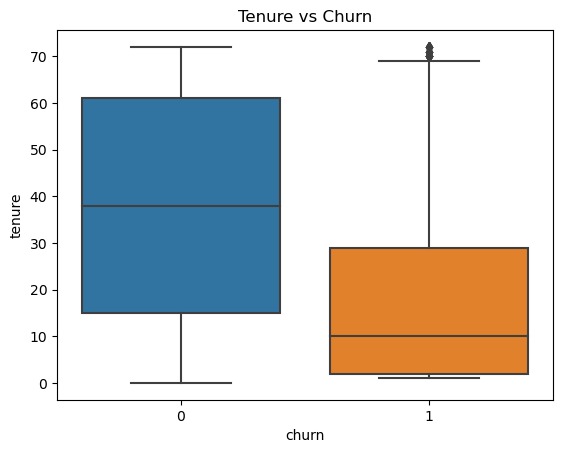

In [32]:
sns.boxplot(x="churn",y="tenure",data=df)
plt.title("Tenure vs Churn")
plt.show()

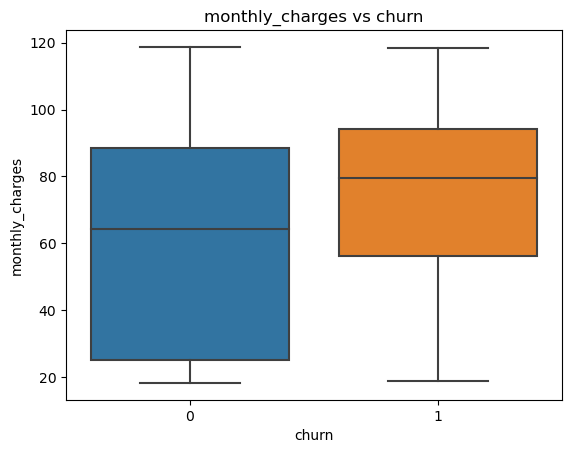

In [33]:
# Monthly charges vs churn 
sns.boxplot(x="churn",y="monthly_charges",data=df)
plt.title("monthly_charges vs churn")
plt.show()

In [34]:
# Catagorical Geatures vs churn

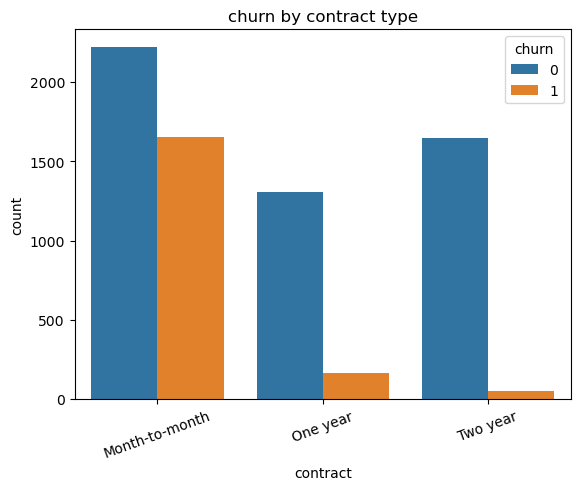

In [35]:
sns.countplot(x="contract",hue="churn",data=df)
plt.title("churn by contract type")
plt.xticks(rotation=20)
plt.show()

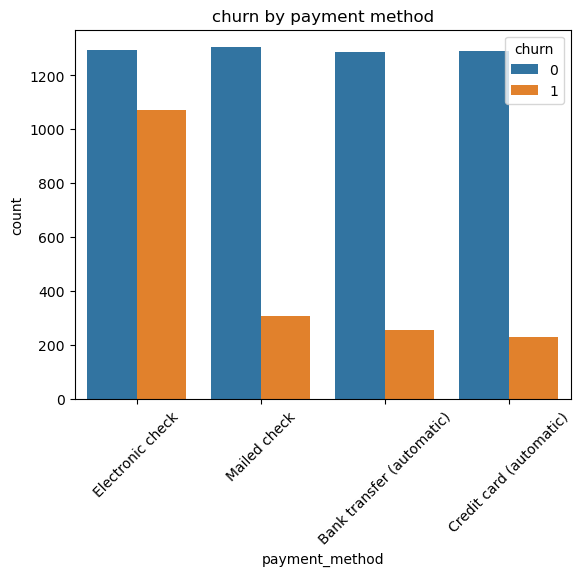

In [36]:
sns.countplot(x="payment_method",hue="churn",data=df)
plt.title("churn by payment method")
plt.xticks(rotation=45)
plt.show()

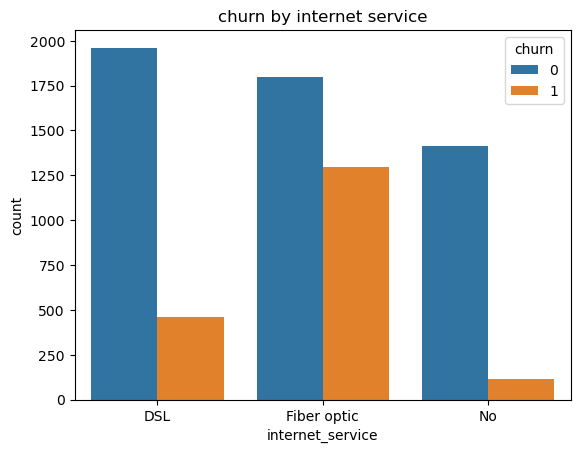

In [37]:
sns.countplot(x="internet_service",hue="churn",data=df)
plt.title("churn by internet service")
plt.show()

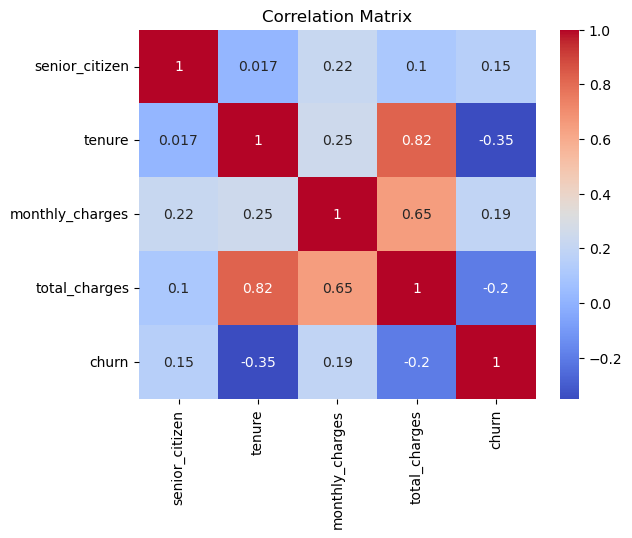

In [39]:
# Correlation 
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [42]:
df.to_csv("../data/cleaned/cleaned_telco_churn.csv",index=False)